<a href="https://colab.research.google.com/github/ilincabaiasu/IB9AU/blob/main/Task_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Required Task 6

## Details

Instructions:

The code below gets a dataset to predict default. The outcome variable of interest is
`default.payment.next.month`.   
   
Use two traditional machine learning algorithms (random
forest, XGboost, etc.) and TabPFN to predict the outcome. Use a test set of 25% of the data. How well does TabPFN perform in comparison to machine learning algorithms?

```

import kagglehub
import pandas as pd
import os

dataset_path = kagglehub.dataset_download("uciml/default-of-credit-card-clients-dataset")

# List contents of the downloaded dataset directory to find the data file
files_in_dataset = os.listdir(dataset_path)
print(f"Files in the dataset directory: {files_in_dataset}")

# Assuming the main data file is a CSV and is directly in the downloaded path
# You might need to adjust the filename if it's different or in a subdirectory
# For this dataset, it's typically 'UCI_Credit_Card.csv'

# Construct the full path to the CSV file
csv_file_name = 'UCI_Credit_Card.csv'
full_csv_path = os.path.join(dataset_path, csv_file_name)

# Load the CSV into a pandas DataFrame
df = pd.read_csv(full_csv_path)

print("Data loaded into DataFrame 'df' successfully.")
print(df.head())
     ```

### What I found interesting:
- Using a different type of model. with no training from scratch -> TabPFN
- The performance comparison shows what different models are good & bad at (e.g. XGBoost ahead, Random Forest close behind, and TabPFN competitive despite having done no work, however TabPFN starts to struggle at scale unlike XGBoost)

| Model | Type | Key trait |
|-------|------|-----------|
| Random Forest | Ensemble of decision trees | Strong baseline, interpretable feature importance |
| XGBoost | Gradient-boosted trees | State-of-the-art for tabular data |
| TabPFN | Pre-trained Transformer | Zero-shot in-context learner — no training from scratch |

### Load dataset

In [1]:
import kagglehub
import pandas as pd
import os

dataset_path = kagglehub.dataset_download("uciml/default-of-credit-card-clients-dataset")

# List contents of the downloaded dataset directory to find the data file
files_in_dataset = os.listdir(dataset_path)
print(f"Files in the dataset directory: {files_in_dataset}")

# Construct the full path to the CSV file
csv_file_name = 'UCI_Credit_Card.csv'
full_csv_path = os.path.join(dataset_path, csv_file_name)

# Load the CSV into a pandas DataFrame
df = pd.read_csv(full_csv_path)

print("Data loaded into DataFrame 'df' successfully.")
print(df.head())

Using Colab cache for faster access to the 'default-of-credit-card-clients-dataset' dataset.
Files in the dataset directory: ['UCI_Credit_Card.csv']
Data loaded into DataFrame 'df' successfully.
   ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
0   1    20000.0    2          2         1   24      2      2     -1     -1   
1   2   120000.0    2          2         2   26     -1      2      0      0   
2   3    90000.0    2          2         2   34      0      0      0      0   
3   4    50000.0    2          2         1   37      0      0      0      0   
4   5    50000.0    1          2         1   57     -1      0     -1      0   

   ...  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  \
0  ...        0.0        0.0        0.0       0.0     689.0       0.0   
1  ...     3272.0     3455.0     3261.0       0.0    1000.0    1000.0   
2  ...    14331.0    14948.0    15549.0    1518.0    1500.0    1000.0   
3  ...    28314.0    28959.0    29547.

### EDA

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

print(f"Shape: {df.shape}")
print(f"\nColumn names:\n{list(df.columns)}")
print(f"\nMissing values: {df.isnull().sum().sum()}")
print(f"\nData types:\n{df.dtypes.value_counts()}")
df

Shape: (30000, 25)

Column names:
['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default.payment.next.month']

Missing values: 0

Data types:
float64    13
int64      12
Name: count, dtype: int64


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29996,220000.0,1,3,1,39,0,0,0,0,...,88004.0,31237.0,15980.0,8500.0,20000.0,5003.0,3047.0,5000.0,1000.0,0
29996,29997,150000.0,1,3,2,43,-1,-1,-1,-1,...,8979.0,5190.0,0.0,1837.0,3526.0,8998.0,129.0,0.0,0.0,0
29997,29998,30000.0,1,2,2,37,4,3,2,-1,...,20878.0,20582.0,19357.0,0.0,0.0,22000.0,4200.0,2000.0,3100.0,1
29998,29999,80000.0,1,3,1,41,1,-1,0,0,...,52774.0,11855.0,48944.0,85900.0,3409.0,1178.0,1926.0,52964.0,1804.0,1


Class distribution:
                            Count  Percentage (%)
default.payment.next.month                       
0                           23364           77.88
1                            6636           22.12


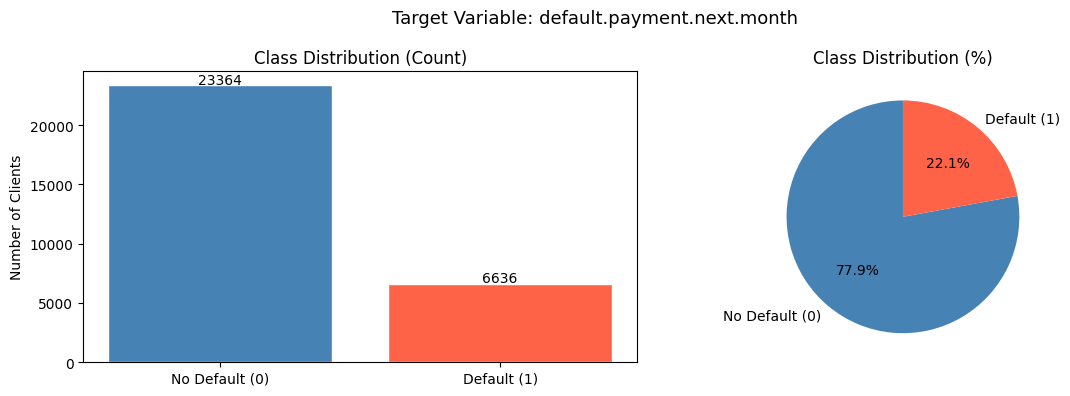

In [3]:
# Class balance
target_col = 'default.payment.next.month'
class_counts = df[target_col].value_counts()
class_pct    = df[target_col].value_counts(normalize=True) * 100

print("Class distribution:")
print(pd.DataFrame({'Count': class_counts, 'Percentage (%)': class_pct.round(2)}))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['No Default (0)', 'Default (1)'], class_counts.values,
            color=['steelblue', 'tomato'], edgecolor='white')
axes[0].set_title('Class Distribution (Count)', fontsize=12)
axes[0].set_ylabel('Number of Clients')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 100, str(v), ha='center', fontsize=10)

axes[1].pie(class_counts.values, labels=['No Default (0)', 'Default (1)'],
            colors=['steelblue', 'tomato'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Class Distribution (%)', fontsize=12)

plt.suptitle('Target Variable: default.payment.next.month', fontsize=13)
plt.tight_layout()
plt.show()

Prep Features & Split Data

In [4]:
from sklearn.model_selection import train_test_split

# Drop the ID column — it is a row identifier, not a feature
df_clean = df.drop(columns=['ID'])

# Separate features (X) and target (y)
target_col = 'default.payment.next.month'
X = df_clean.drop(columns=[target_col])
y = df_clean[target_col]

# Split: 75% train, 25% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"Training samples : {len(X_train):,}")
print(f"Test samples     : {len(X_test):,}")
print(f"Features         : {X_train.shape[1]}")
print(f"\nClass balance in test set:")
print(y_test.value_counts(normalize=True).round(3))

Training samples : 22,500
Test samples     : 7,500
Features         : 23

Class balance in test set:
default.payment.next.month
0    0.779
1    0.221
Name: proportion, dtype: float64


### Model 1: Random Forest Classifier

In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

# Initialize and train the Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Make predictions on the test set
rf_pred       = rf_model.predict(X_test)
rf_pred_proba = rf_model.predict_proba(X_test)[:, 1]

# Evaluate the model
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_roc_auc  = roc_auc_score(y_test, rf_pred_proba)
rf_report   = classification_report(y_test, rf_pred)

print("=" * 45)
print("Random Forest Results")
print("=" * 45)
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"ROC AUC  : {rf_roc_auc:.4f}")
print("\nClassification Report:")
print(rf_report)

Random Forest Results
Accuracy : 0.8136
ROC AUC  : 0.7524

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.94      0.89      5841
           1       0.64      0.37      0.47      1659

    accuracy                           0.81      7500
   macro avg       0.74      0.65      0.68      7500
weighted avg       0.79      0.81      0.79      7500



### Model 2: XGBoost Classifier

In [6]:
from xgboost import XGBClassifier

# Compute scale_pos_weight to handle class imbalance
# = count(no default) / count(default)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

# Initialize and train the XGBoost Classifier
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)
xgb_model.fit(X_train, y_train)

# Make predictions on the test set
xgb_pred       = xgb_model.predict(X_test)
xgb_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

# Evaluate the model
xgb_accuracy = accuracy_score(y_test, xgb_pred)
xgb_roc_auc  = roc_auc_score(y_test, xgb_pred_proba)
xgb_report   = classification_report(y_test, xgb_pred)

print("\n" + "=" * 45)
print("XGBoost Results")
print("=" * 45)
print(f"Accuracy : {xgb_accuracy:.4f}")
print(f"ROC AUC  : {xgb_roc_auc:.4f}")
print("\nClassification Report:")
print(xgb_report)

scale_pos_weight: 3.52

XGBoost Results
Accuracy : 0.7600
ROC AUC  : 0.7757

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.80      0.84      5841
           1       0.47      0.60      0.53      1659

    accuracy                           0.76      7500
   macro avg       0.67      0.70      0.68      7500
weighted avg       0.79      0.76      0.77      7500



### Model 3: TabPFN

In [14]:
pip install tabpfn_client

In [19]:
import tabpfn_client
import os

# Retrieve the API key from the environment variable (set by Colab Secrets or manually)
api_key = os.environ.get('TABPFN_API_KEY')

if api_key:
    tabpfn_client.set_access_token(api_key)
    print("TabPFN API key successfully set.")
else:
    print("Error: TABPFN_API_KEY environment variable not found. Please ensure it's set.")
    print("You can also manually replace 'TABPFN_API_KEY' in the line below with your actual key if not using Colab Secrets.")
    # Example of manual setting (replace with your actual key if not using environment variable):
    # tabpfn_client.set_access_token("YOUR_ACTUAL_TABPFN_API_KEY_HERE")

TabPFN API key successfully set.


In [20]:
from tabpfn_client import TabPFNClassifier

# Initialize and train the TabPFN Classifier
# *** First time running: you will be prompted to create a free account ***
tabpfn_model = TabPFNClassifier(random_state=42)
tabpfn_model.fit(X_train, y_train)

# Make predictions on the test set
tabpfn_pred_proba = tabpfn_model.predict_proba(X_test)
tabpfn_pred       = tabpfn_model.predict(X_test)

# Evaluate the model
tabpfn_accuracy = accuracy_score(y_test, tabpfn_pred)
tabpfn_roc_auc  = roc_auc_score(y_test, tabpfn_pred_proba[:, 1])
tabpfn_report   = classification_report(y_test, tabpfn_pred)

print("=" * 45)
print("TabPFN Results")
print("=" * 45)
print(f"Accuracy : {tabpfn_accuracy:.4f}")
print(f"ROC AUC  : {tabpfn_roc_auc:.4f}")
print("\nClassification Report:")
print(tabpfn_report)

Processing: 100%|██████████| [00:05<00:00]
Processing: 100%|██████████| [00:04<00:00]


TabPFN Results
Accuracy : 0.8187
ROC AUC  : 0.7856

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      5841
           1       0.66      0.37      0.47      1659

    accuracy                           0.82      7500
   macro avg       0.75      0.66      0.68      7500
weighted avg       0.80      0.82      0.80      7500



### Comparison

In [21]:
import numpy as np

# Summary table
results = pd.DataFrame({
    'Model'   : ['Random Forest', 'XGBoost', 'TabPFN'],
    'Accuracy': [rf_accuracy, xgb_accuracy, tabpfn_accuracy],
    'ROC AUC' : [rf_roc_auc,  xgb_roc_auc,  tabpfn_roc_auc]
})
results['Accuracy'] = results['Accuracy'].map('{:.4f}'.format)
results['ROC AUC']  = results['ROC AUC'].map('{:.4f}'.format)

print("\nModel Comparison Summary:")
print(results.to_string(index=False))


Model Comparison Summary:
        Model Accuracy ROC AUC
Random Forest   0.8136  0.7524
      XGBoost   0.7600  0.7757
       TabPFN   0.8187  0.7856


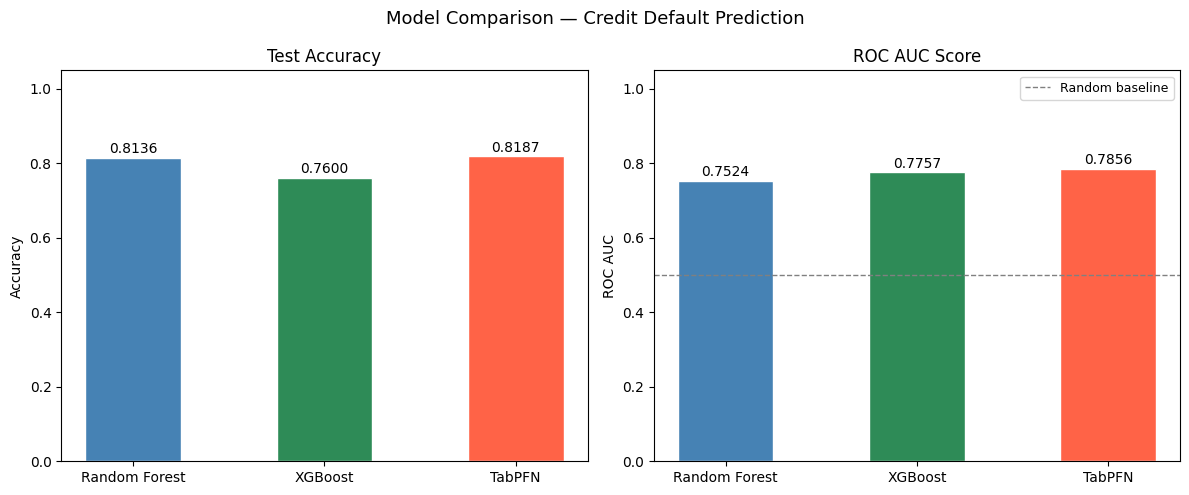

In [22]:
models   = ['Random Forest', 'XGBoost', 'TabPFN']
accuracy = [rf_accuracy, xgb_accuracy, tabpfn_accuracy]
roc_auc  = [rf_roc_auc,  xgb_roc_auc,  tabpfn_roc_auc]
colors   = ['steelblue', 'seagreen', 'tomato']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Accuracy bar chart
bars = axes[0].bar(models, accuracy, color=colors, edgecolor='white', width=0.5)
axes[0].set_ylim(0, 1.05)
axes[0].set_title('Test Accuracy', fontsize=12)
axes[0].set_ylabel('Accuracy')
for bar, val in zip(bars, accuracy):
    axes[0].text(bar.get_x() + bar.get_width() / 2, val + 0.005,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=10)

# ROC AUC bar chart
bars = axes[1].bar(models, roc_auc, color=colors, edgecolor='white', width=0.5)
axes[1].set_ylim(0, 1.05)
axes[1].set_title('ROC AUC Score', fontsize=12)
axes[1].set_ylabel('ROC AUC')
axes[1].axhline(0.5, color='grey', linestyle='--', linewidth=1, label='Random baseline')
axes[1].legend(fontsize=9)
for bar, val in zip(bars, roc_auc):
    axes[1].text(bar.get_x() + bar.get_width() / 2, val + 0.005,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=10)

plt.suptitle('Model Comparison — Credit Default Prediction', fontsize=13)
plt.tight_layout()
plt.show()

### ROC Curves

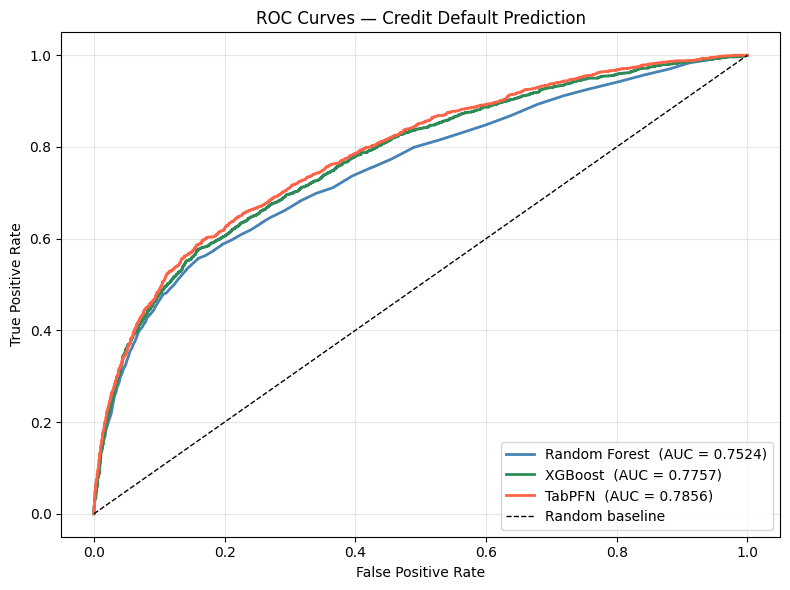

In [23]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8, 6))

for name, proba, color in [
    ('Random Forest', rf_pred_proba,     'steelblue'),
    ('XGBoost',       xgb_pred_proba,    'seagreen'),
    ('TabPFN',        tabpfn_pred_proba[:, 1], 'tomato')
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name}  (AUC = {auc:.4f})', color=color, linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Credit Default Prediction', fontsize=12)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Feature Importance (RF & XGB)

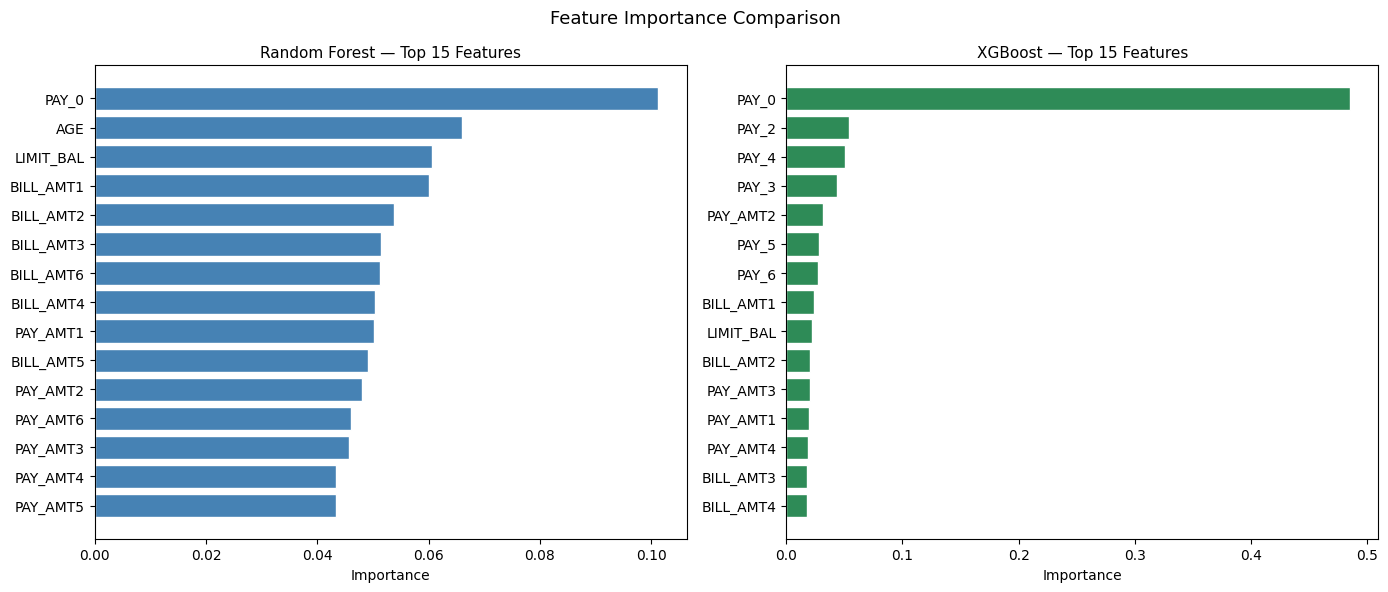

In [24]:
# Extract feature importances from both models
rf_importance  = pd.Series(rf_model.feature_importances_,  index=X.columns)
xgb_importance = pd.Series(xgb_model.feature_importances_, index=X.columns)

top_n = 15
rf_top  = rf_importance.nlargest(top_n).sort_values()
xgb_top = xgb_importance.nlargest(top_n).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(rf_top.index, rf_top.values, color='steelblue', edgecolor='white')
axes[0].set_title(f'Random Forest — Top {top_n} Features', fontsize=11)
axes[0].set_xlabel('Importance')

axes[1].barh(xgb_top.index, xgb_top.values, color='seagreen', edgecolor='white')
axes[1].set_title(f'XGBoost — Top {top_n} Features', fontsize=11)
axes[1].set_xlabel('Importance')

plt.suptitle('Feature Importance Comparison', fontsize=13)
plt.tight_layout()
plt.show()